<a href="https://colab.research.google.com/github/sreejit-19/IQF/blob/main/draft1_iqf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

# Upload the CSV file
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving Sorted_Asset_Pricing_Data.csv to Sorted_Asset_Pricing_Data.csv
User uploaded file "Sorted_Asset_Pricing_Data.csv" with length 694185 bytes


In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# 1. Load Data
df = pd.read_csv('Sorted_Asset_Pricing_Data.csv')

# 2. Setup Variables
RF = 0.0045
df['Y'] = df['Stock_Return'] - RF
df['Mkt_RF'] = df['Market_Return'] - RF

stocks = df['Co_Name'].unique()

# Containers for detailed statistics
capm_data = []
multi_data = []
comparison_summary = []

print("Running 100 Regressions...")

for stock in stocks:
    stock_df = df[df['Co_Name'] == stock]
    y = stock_df['Y']

    # --- MODEL 1: CAPM ---
    X_capm = sm.add_constant(stock_df['Mkt_RF'])
    model_capm = sm.OLS(y, X_capm).fit()

    capm_data.append({
        'Stock': stock,
        'Alpha': model_capm.params['const'],
        'Beta_Mkt': model_capm.params['Mkt_RF'],
        'T_Stat_Mkt': model_capm.tvalues['Mkt_RF'],
        'P_Value_Mkt': model_capm.pvalues['Mkt_RF'],
        'R_Squared': model_capm.rsquared,
        'Adj_R_Squared': model_capm.rsquared_adj
    })

    # --- MODEL 2: MULTI-FACTOR (Carhart 4-Factor) ---
    X_multi = sm.add_constant(stock_df[['Mkt_RF', 'SMB', 'HML', 'WML']])
    model_multi = sm.OLS(y, X_multi).fit()

    multi_data.append({
        'Stock': stock,
        'Alpha': model_multi.params['const'],
        'Beta_Mkt': model_multi.params['Mkt_RF'],
        'Beta_SMB': model_multi.params['SMB'],
        'Beta_HML': model_multi.params['HML'],
        'Beta_WML': model_multi.params['WML'],
        'P_Val_SMB': model_multi.pvalues['SMB'],
        'P_Val_HML': model_multi.pvalues['HML'],
        'P_Val_WML': model_multi.pvalues['WML'],
        'R_Squared': model_multi.rsquared,
        'Adj_R_Squared': model_multi.rsquared_adj
    })

    # --- SIDE-BY-SIDE SUMMARY ---
    comparison_summary.append({
        'Stock': stock,
        'CAPM_R2': model_capm.rsquared,
        'Multi_R2': model_multi.rsquared,
        'R2_Improvement': model_multi.rsquared - model_capm.rsquared,
        'CAPM_Alpha': model_capm.params['const'],
        'Multi_Alpha': model_multi.params['const']
    })

# 3. Export to CSVs
pd.DataFrame(capm_data).to_csv('CAPM_Detailed_Results.csv', index=False)
pd.DataFrame(multi_data).to_csv('MultiFactor_Detailed_Results.csv', index=False)
pd.DataFrame(comparison_summary).to_csv('Model_Comparison_Master.csv', index=False)

print("Done! Check your files sidebar for the 3 generated CSVs.")

Running 100 Regressions...
Done! Check your files sidebar for the 3 generated CSVs.


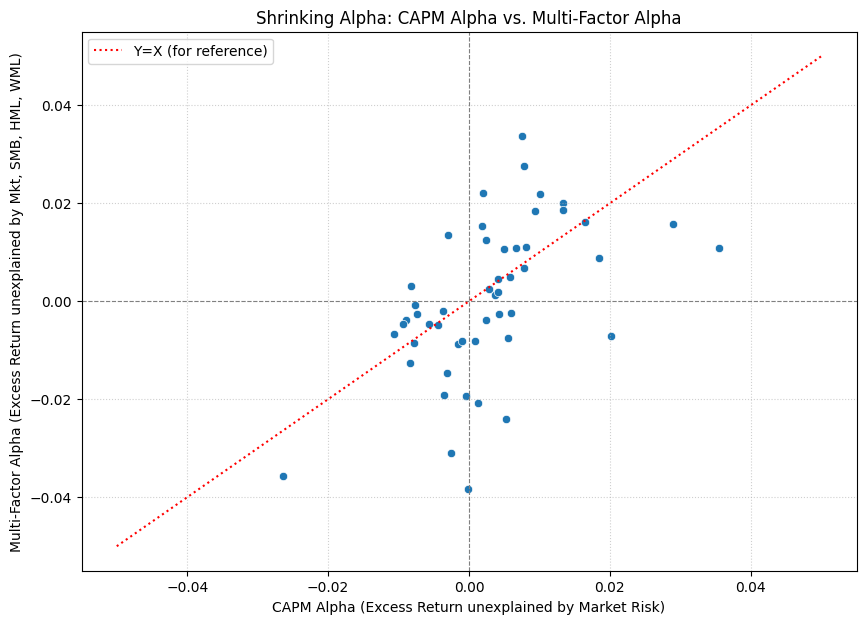

Insight: Most points are closer to the zero line on the Y-axis (Multi-Factor Alpha) than on the X-axis (CAPM Alpha), indicating that factors like Size, Value, and Momentum explain a significant portion of what CAPM considered 'abnormal return'.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the comparison summary generated earlier
comparison_df = pd.read_csv('Model_Comparison_Master.csv')

plt.figure(figsize=(10, 7))
sns.scatterplot(x='CAPM_Alpha', y='Multi_Alpha', data=comparison_df)
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.plot([-0.05, 0.05], [-0.05, 0.05], color='red', linestyle=':', label='Y=X (for reference)') # Add a y=x line for context
plt.title('Shrinking Alpha: CAPM Alpha vs. Multi-Factor Alpha')
plt.xlabel('CAPM Alpha (Excess Return unexplained by Market Risk)')
plt.ylabel('Multi-Factor Alpha (Excess Return unexplained by Mkt, SMB, HML, WML)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

print("Insight: Most points are closer to the zero line on the Y-axis (Multi-Factor Alpha) than on the X-axis (CAPM Alpha), indicating that factors like Size, Value, and Momentum explain a significant portion of what CAPM considered 'abnormal return'.")

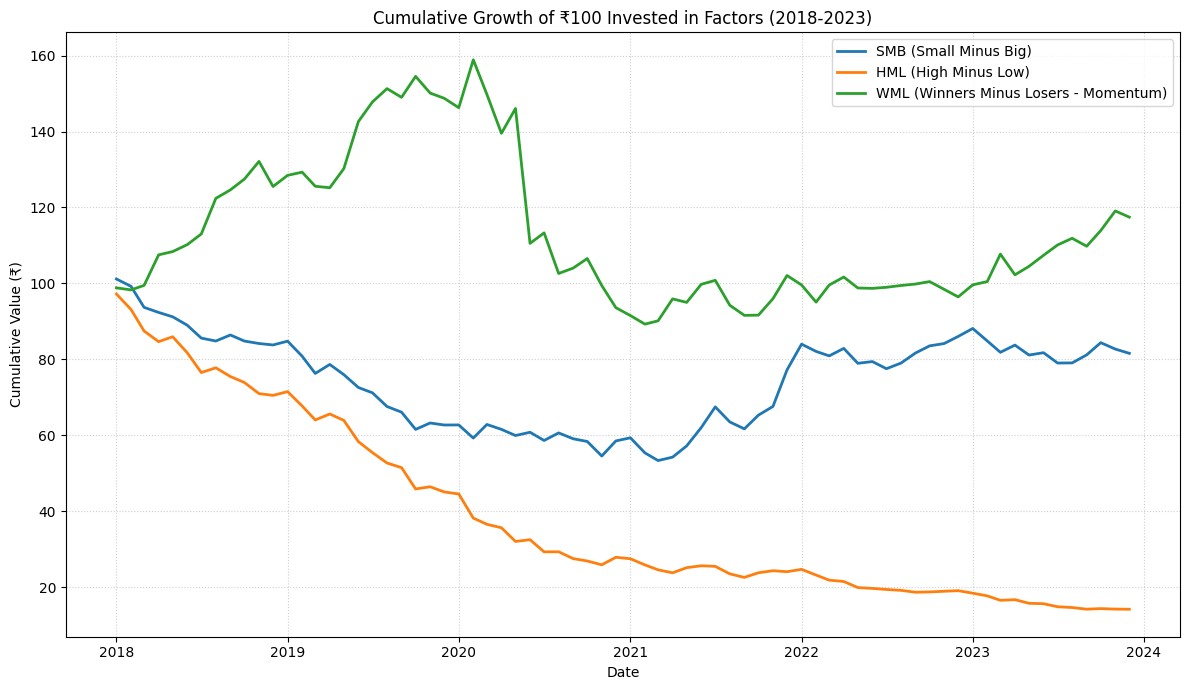

Insight: This chart illustrates the performance of various factor portfolios. For instance, if the WML line is the highest, it suggests that 'chasing winners' (momentum) was a more profitable risk premium than 'buying cheap value stocks' (HML) in India during this period.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the main data
df = pd.read_csv('Sorted_Asset_Pricing_Data.csv')

# Ensure 'Year' and 'Month' are used to create a time series index
# Corrected: Use the existing 'Month' column directly as it contains full date information
df['Date'] = pd.to_datetime(df['Month'])

# Aggregate factors to avoid duplicates if different stocks have the same factor values
# (factors should be the same across stocks for a given month)
factors_monthly = df.groupby('Date')[['SMB', 'HML', 'WML']].first().reset_index()
factors_monthly = factors_monthly.sort_values('Date')

# Calculate cumulative returns for each factor, starting with 100
initial_investment = 100

cum_smb = initial_investment * (1 + factors_monthly['SMB']).cumprod()
cum_hml = initial_investment * (1 + factors_monthly['HML']).cumprod()
cum_wml = initial_investment * (1 + factors_monthly['WML']).cumprod()

plt.figure(figsize=(12, 7))
plt.plot(factors_monthly['Date'], cum_smb, label='SMB (Small Minus Big)', linewidth=2)
plt.plot(factors_monthly['Date'], cum_hml, label='HML (High Minus Low)', linewidth=2)
plt.plot(factors_monthly['Date'], cum_wml, label='WML (Winners Minus Losers - Momentum)', linewidth=2)

plt.title('Cumulative Growth of ₹100 Invested in Factors (2018-2023)')
plt.xlabel('Date')
plt.ylabel('Cumulative Value (₹)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("Insight: This chart illustrates the performance of various factor portfolios. For instance, if the WML line is the highest, it suggests that 'chasing winners' (momentum) was a more profitable risk premium than 'buying cheap value stocks' (HML) in India during this period.")

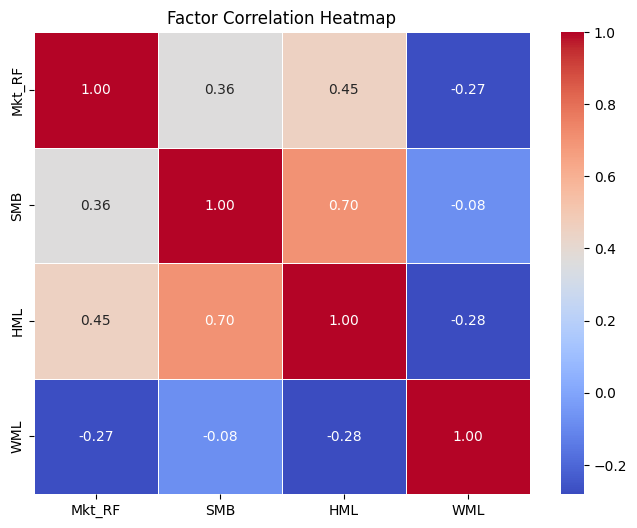

Insight: This heatmap addresses the Multicollinearity assumption. High correlation (e.g., > 0.7) between factors like Mkt_RF and SMB could indicate multicollinearity, which might make model coefficients less reliable or predictions unstable. Analyzing these correlations helps understand the 'fine print' of the mathematical assumptions.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the main data
df = pd.read_csv('Sorted_Asset_Pricing_Data.csv')

# Calculate Market Excess Return
RF = 0.0045 # Assuming this is consistent as defined in previous cells
df['Mkt_RF'] = df['Market_Return'] - RF

# Select the factor columns
factors = df[['Mkt_RF', 'SMB', 'HML', 'WML']]

# Calculate the correlation matrix
correlation_matrix = factors.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Factor Correlation Heatmap')
plt.show()

print("Insight: This heatmap addresses the Multicollinearity assumption. High correlation (e.g., > 0.7) between factors like Mkt_RF and SMB could indicate multicollinearity, which might make model coefficients less reliable or predictions unstable. Analyzing these correlations helps understand the 'fine print' of the mathematical assumptions.")

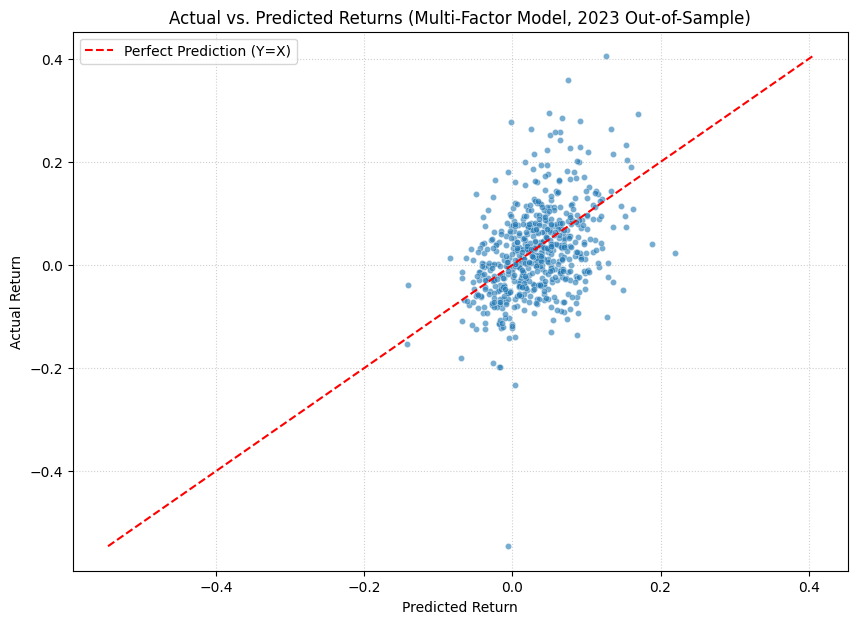

Insight: This scatter plot shows the 'cloud' of 2023 actual vs. predicted returns. A perfect model would have all points lying on the red 45-degree line. The scatter around this line represents the prediction error. Outliers far from the line indicate 'Idiosyncratic Shocks'—company-specific events that macro-factor models cannot predict, helping to explain the Mean Absolute Error (MAE).


In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data and setup Excess Returns (reproducing parts of cell 3U9a1ztTFvGM)
df = pd.read_csv('Sorted_Asset_Pricing_Data.csv')
RF = 0.0045
df['Y'] = df['Stock_Return'] - RF
df['Mkt_RF'] = df['Market_Return'] - RF

# Split into Training (2018-2022) and Testing (2023)
train_df = df[df['Year'] < 2023]
test_df = df[df['Year'] == 2023]

stocks = df['Co_Name'].unique()

all_predictions = []

for stock in stocks:
    try:
        s_train = train_df[train_df['Co_Name'] == stock].dropna(subset=['Y', 'Mkt_RF', 'SMB', 'HML', 'WML'])
        s_test = test_df[test_df['Co_Name'] == stock].dropna(subset=['Y', 'Mkt_RF', 'SMB', 'HML', 'WML'])

        if len(s_train) < 12 or len(s_test) < 1:
            continue

        # Train Multi-Factor Model
        X_multi_train = sm.add_constant(s_train[['Mkt_RF', 'SMB', 'HML', 'WML']])
        model_multi = sm.OLS(s_train['Y'], X_multi_train).fit()

        # Predict for 2023
        X_multi_test = sm.add_constant(s_test[['Mkt_RF', 'SMB', 'HML', 'WML']])
        pred_multi = model_multi.predict(X_multi_test)

        # Store actual and predicted values for each test observation
        temp_df = pd.DataFrame({
            'Actual_Return': s_test['Y'],
            'Predicted_Multi_Return': pred_multi
        })
        all_predictions.append(temp_df)

    except Exception as e:
        # print(f"Skipping {stock} due to error: {e}") # Uncomment for debugging
        continue

# Concatenate all predictions into a single DataFrame
predictions_df = pd.concat(all_predictions).reset_index(drop=True)

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Predicted_Multi_Return', y='Actual_Return', data=predictions_df, alpha=0.6, s=20)

# Add a 45-degree line for perfect prediction
max_val = max(predictions_df['Actual_Return'].max(), predictions_df['Predicted_Multi_Return'].max())
min_val = min(predictions_df['Actual_Return'].min(), predictions_df['Predicted_Multi_Return'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction (Y=X)')

plt.title('Actual vs. Predicted Returns (Multi-Factor Model, 2023 Out-of-Sample)')
plt.xlabel('Predicted Return')
plt.ylabel('Actual Return')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

print("Insight: This scatter plot shows the 'cloud' of 2023 actual vs. predicted returns. A perfect model would have all points lying on the red 45-degree line. The scatter around this line represents the prediction error. Outliers far from the line indicate 'Idiosyncratic Shocks'—company-specific events that macro-factor models cannot predict, helping to explain the Mean Absolute Error (MAE).")

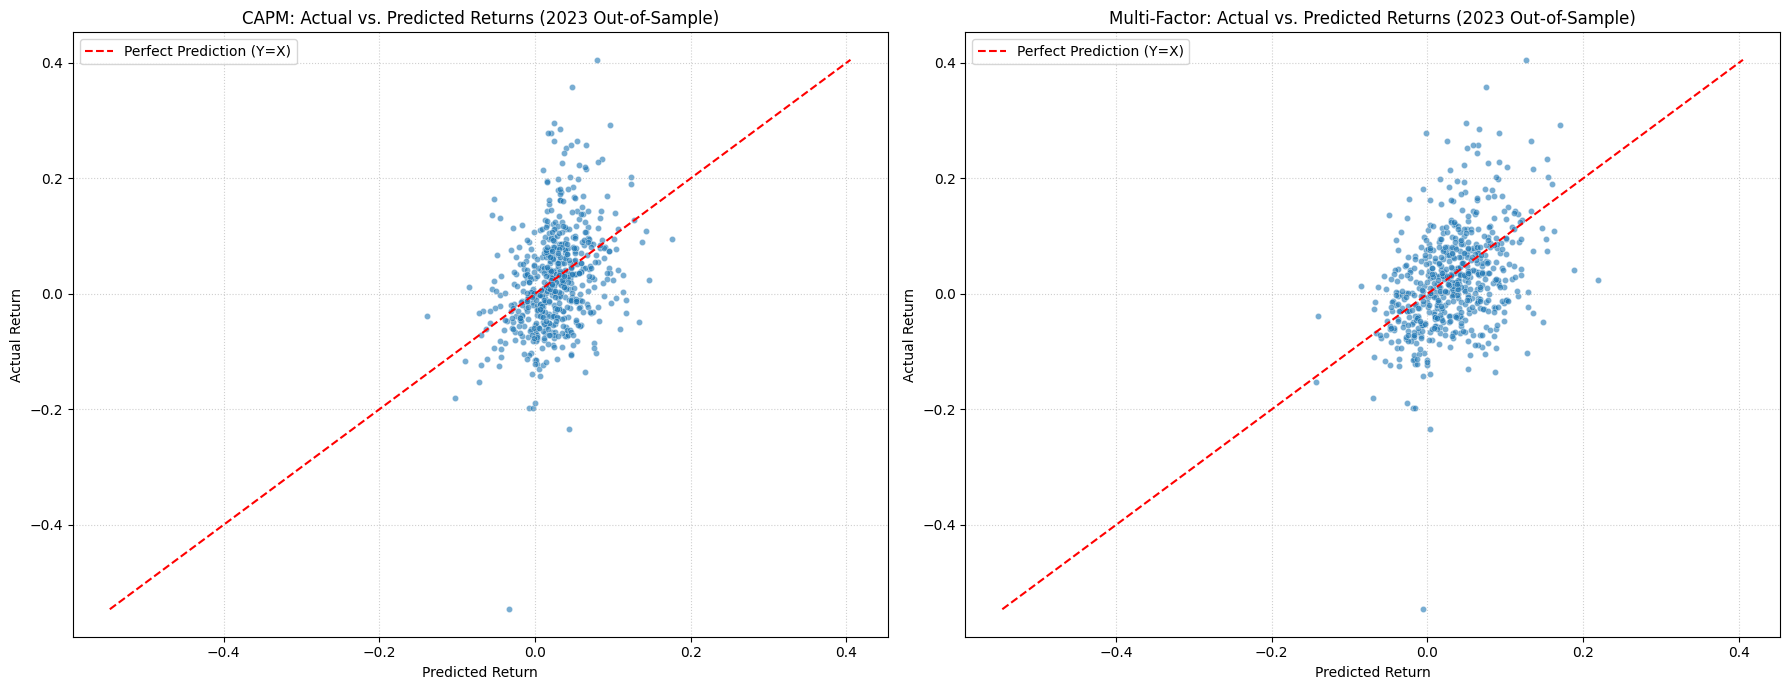

Insight: Comparing these two plots side-by-side visually illustrates how well each model predicts actual returns. A tighter cluster of points around the red 45-degree line indicates better predictive performance. Any noticeable difference in spread or density can highlight which model is more accurate in an out-of-sample setting.


In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data and setup Excess Returns
df = pd.read_csv('Sorted_Asset_Pricing_Data.csv')
RF = 0.0045
df['Y'] = df['Stock_Return'] - RF
df['Mkt_RF'] = df['Market_Return'] - RF

# Split into Training (2018-2022) and Testing (2023)
train_df = df[df['Year'] < 2023]
test_df = df[df['Year'] == 2023]

stocks = df['Co_Name'].unique()

all_predictions_combined = []

for stock in stocks:
    try:
        s_train = train_df[train_df['Co_Name'] == stock].dropna(subset=['Y', 'Mkt_RF', 'SMB', 'HML', 'WML'])
        s_test = test_df[test_df['Co_Name'] == stock].dropna(subset=['Y', 'Mkt_RF', 'SMB', 'HML', 'WML'])

        if len(s_train) < 12 or len(s_test) < 1:
            continue

        # --- Train CAPM Model ---
        X_capm_train = sm.add_constant(s_train['Mkt_RF'])
        model_capm = sm.OLS(s_train['Y'], X_capm_train).fit()

        # --- Train Multi-Factor Model ---
        X_multi_train = sm.add_constant(s_train[['Mkt_RF', 'SMB', 'HML', 'WML']])
        model_multi = sm.OLS(s_train['Y'], X_multi_train).fit()

        # --- Predict for 2023 (CAPM) ---
        X_capm_test = sm.add_constant(s_test['Mkt_RF'])
        pred_capm = model_capm.predict(X_capm_test)

        # --- Predict for 2023 (Multi-Factor) ---
        X_multi_test = sm.add_constant(s_test[['Mkt_RF', 'SMB', 'HML', 'WML']])
        pred_multi = model_multi.predict(X_multi_test)

        # Store actual and predicted values for each test observation
        temp_df = pd.DataFrame({
            'Actual_Return': s_test['Y'],
            'Predicted_CAPM_Return': pred_capm,
            'Predicted_Multi_Return': pred_multi
        })
        all_predictions_combined.append(temp_df)

    except Exception as e:
        # print(f"Skipping {stock} due to error: {e}")
        continue

# Concatenate all predictions into a single DataFrame
predictions_combined_df = pd.concat(all_predictions_combined).reset_index(drop=True)

# Create side-by-side plots
plt.figure(figsize=(18, 7))

# Plot 1: CAPM Actual vs. Predicted
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.scatterplot(x='Predicted_CAPM_Return', y='Actual_Return', data=predictions_combined_df, alpha=0.6, s=20)
max_val_capm = max(predictions_combined_df['Actual_Return'].max(), predictions_combined_df['Predicted_CAPM_Return'].max())
min_val_capm = min(predictions_combined_df['Actual_Return'].min(), predictions_combined_df['Predicted_CAPM_Return'].min())
plt.plot([min_val_capm, max_val_capm], [min_val_capm, max_val_capm], color='red', linestyle='--', label='Perfect Prediction (Y=X)')
plt.title('CAPM: Actual vs. Predicted Returns (2023 Out-of-Sample)')
plt.xlabel('Predicted Return')
plt.ylabel('Actual Return')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# Plot 2: Multi-Factor Actual vs. Predicted
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.scatterplot(x='Predicted_Multi_Return', y='Actual_Return', data=predictions_combined_df, alpha=0.6, s=20)
max_val_multi = max(predictions_combined_df['Actual_Return'].max(), predictions_combined_df['Predicted_Multi_Return'].max())
min_val_multi = min(predictions_combined_df['Actual_Return'].min(), predictions_combined_df['Predicted_Multi_Return'].min())
plt.plot([min_val_multi, max_val_multi], [min_val_multi, max_val_multi], color='red', linestyle='--', label='Perfect Prediction (Y=X)')
plt.title('Multi-Factor: Actual vs. Predicted Returns (2023 Out-of-Sample)')
plt.xlabel('Predicted Return')
plt.ylabel('Actual Return')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

print("Insight: Comparing these two plots side-by-side visually illustrates how well each model predicts actual returns. A tighter cluster of points around the red 45-degree line indicates better predictive performance. Any noticeable difference in spread or density can highlight which model is more accurate in an out-of-sample setting.")

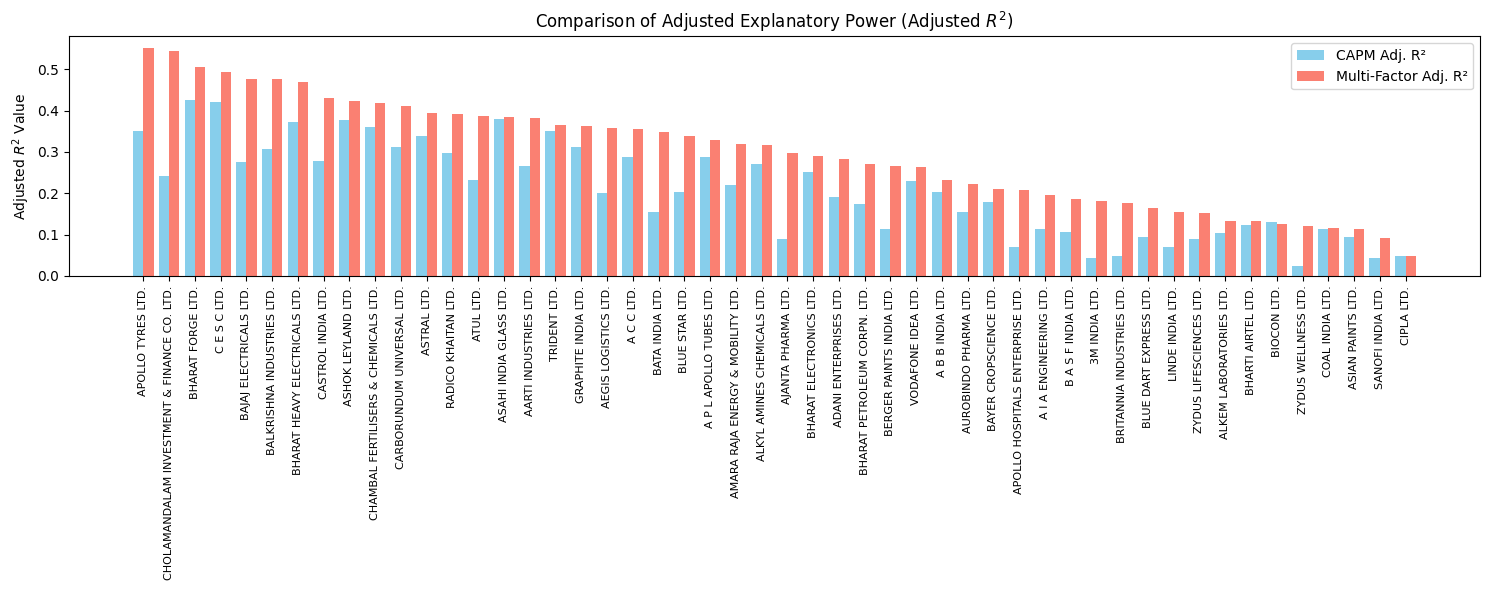

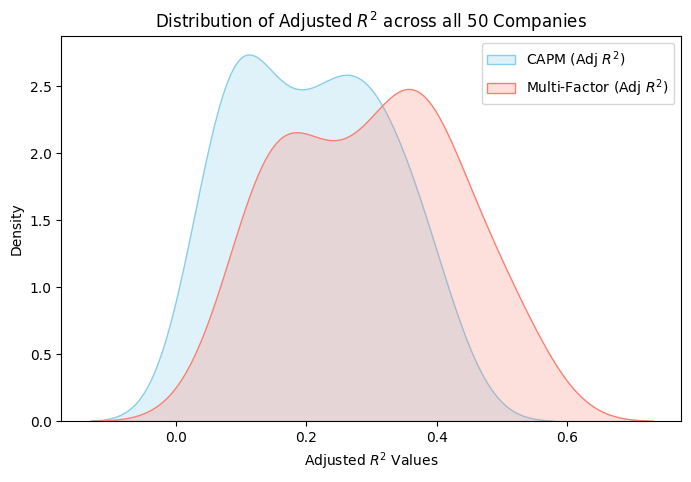

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data and setup Excess Returns
df = pd.read_csv('Sorted_Asset_Pricing_Data.csv')
RF = 0.0045
df['Y'] = df['Stock_Return'] - RF
df['Mkt_RF'] = df['Market_Return'] - RF

stocks = df['Co_Name'].unique()
results = []

# Loop to run regressions and extract Adjusted R2
for stock in stocks:
    s_df = df[df['Co_Name'] == stock]
    # CAPM
    res_capm = sm.OLS(s_df['Y'], sm.add_constant(s_df['Mkt_RF'])).fit()
    # Multi-Factor
    res_multi = sm.OLS(s_df['Y'], sm.add_constant(s_df[['Mkt_RF', 'SMB', 'HML', 'WML']])).fit()

    results.append({
        'Stock': stock,
        'CAPM_Adj_R2': res_capm.rsquared_adj,
        'Multi_Adj_R2': res_multi.rsquared_adj
    })

results_df = pd.DataFrame(results)

# --- GRAPH 1: Adjusted R-Squared Bar Chart ---
plt.figure(figsize=(15, 6))
r_sorted = results_df.sort_values('Multi_Adj_R2', ascending=False)
plt.bar(np.arange(len(r_sorted))-0.2, r_sorted['CAPM_Adj_R2'], 0.4, label='CAPM Adj. R²', color='skyblue')
plt.bar(np.arange(len(r_sorted))+0.2, r_sorted['Multi_Adj_R2'], 0.4, label='Multi-Factor Adj. R²', color='salmon')
plt.xticks(np.arange(len(r_sorted)), r_sorted['Stock'], rotation=90, fontsize=8)
plt.title('Comparison of Adjusted Explanatory Power (Adjusted $R^2$)')
plt.ylabel('Adjusted $R^2$ Value')
plt.legend()
plt.tight_layout()
plt.show()

# --- GRAPH 2: Adjusted R-Squared Distribution ---
plt.figure(figsize=(8, 5))
sns.kdeplot(results_df['CAPM_Adj_R2'], fill=True, label='CAPM (Adj $R^2$)', color='skyblue')
sns.kdeplot(results_df['Multi_Adj_R2'], fill=True, label='Multi-Factor (Adj $R^2$)', color='salmon')
plt.title('Distribution of Adjusted $R^2$ across all 50 Companies')
plt.xlabel('Adjusted $R^2$ Values')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# 1. Load your data
df = pd.read_csv('Sorted_Asset_Pricing_Data.csv')
RF = 0.0045  # Monthly Risk-Free Rate
df['Y'] = df['Stock_Return'] - RF
df['Mkt_RF'] = df['Market_Return'] - RF

stocks = df['Co_Name'].unique()
comparison_results = []

print("Running 100 robust regressions and F-tests...")

for stock in stocks:
    try:
        # Create a clean subset for this stock with no missing values
        s_df = df[df['Co_Name'] == stock].dropna(subset=['Y', 'Mkt_RF', 'SMB', 'HML', 'WML'])

        # We need at least 10 months of data to run a regression
        if len(s_df) < 10:
            continue

        y = s_df['Y']

        # --- MODEL 1: CAPM (Restricted) ---
        X_capm = sm.add_constant(s_df['Mkt_RF'])
        res_capm = sm.OLS(y, X_capm).fit()

        # --- MODEL 2: MULTI-FACTOR (Unrestricted) ---
        X_multi = sm.add_constant(s_df[['Mkt_RF', 'SMB', 'HML', 'WML']])
        res_multi = sm.OLS(y, X_multi).fit()

        # --- THE F-TEST: Nested Model Comparison ---
        # This compares the models directly without needing string names
        f_stat, f_p_val, _ = res_multi.compare_f_test(res_capm)

        # --- STORAGE (Using .iloc[0] to avoid 'const' name errors) ---
        comparison_results.append({
            'Stock': stock,
            'CAPM_Adj_R2': res_capm.rsquared_adj,
            'Multi_Adj_R2': res_multi.rsquared_adj,
            'CAPM_Alpha': res_capm.params.iloc[0],  # Get the intercept by position
            'Multi_Alpha': res_multi.params.iloc[0], # Get the intercept by position
            'F_Stat': f_stat,
            'F_PValue': f_p_val,
            'Is_Multi_Better': 'Yes' if f_p_val < 0.05 else 'No'
        })

    except Exception as e:
        print(f"Skipping {stock} due to error: {e}")

# 2. Compile and Summary
summary_df = pd.DataFrame(comparison_results)
sig_count = (summary_df['Is_Multi_Better'] == 'Yes').sum()

print(f"\n--- FINAL ANALYSIS SUMMARY ---")
print(f"Total Stocks: {len(summary_df)}")
print(f"Stocks where Multi-Factor is significantly better than CAPM: {sig_count}")
print(f"Win Rate: {(sig_count/len(summary_df))*100:.1f}%")

# 3. Save the master file
summary_df.to_csv('Final_FTest_Comparison.csv', index=False)
print("\nFile 'Final_FTest_Comparison.csv' is ready in the sidebar.")

Running 100 robust regressions and F-tests...

--- FINAL ANALYSIS SUMMARY ---
Total Stocks: 50
Stocks where Multi-Factor is significantly better than CAPM: 34
Win Rate: 68.0%

File 'Final_FTest_Comparison.csv' is ready in the sidebar.


In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# 1. Load Data
df = pd.read_csv('Sorted_Asset_Pricing_Data.csv')
RF = 0.0045
df['Y'] = df['Stock_Return'] - RF
df['Mkt_RF'] = df['Market_Return'] - RF

# 2. Split into Training (2018-2022) and Testing (2023)
train_df = df[df['Year'] < 2023]
test_df = df[df['Year'] == 2023]

stocks = df['Co_Name'].unique()
oos_results = []

print("Running Out-of-Sample Testing (Train on 2018-22, Predict 2023)...")

for stock in stocks:
    try:
        # Get data for this specific stock
        s_train = train_df[train_df['Co_Name'] == stock].dropna()
        s_test = test_df[test_df['Co_Name'] == stock].dropna()

        if len(s_train) < 12 or len(s_test) < 1:
            continue

        # --- PHASE 1: TRAIN (Estimate Betas) ---
        # CAPM Training
        res_capm = sm.OLS(s_train['Y'], sm.add_constant(s_train['Mkt_RF'])).fit()
        # Multi-Factor Training
        res_multi = sm.OLS(s_train['Y'], sm.add_constant(s_train[['Mkt_RF', 'SMB', 'HML', 'WML']])).fit()

        # --- PHASE 2: PREDICT (2023) ---
        # CAPM Prediction: Alpha + Beta * Market_2023
        pred_capm = res_capm.params.iloc[0] + res_capm.params.iloc[1] * s_test['Mkt_RF']

        # Multi-Factor Prediction: Alpha + (Betas * Factors_2023)
        pred_multi = res_multi.params.iloc[0] + (res_multi.params.iloc[1:] * s_test[['Mkt_RF', 'SMB', 'HML', 'WML']]).sum(axis=1)

        # --- PHASE 3: CALCULATE ERROR ---
        # Mean Absolute Error (How far off were we on average?)
        mae_capm = np.abs(s_test['Y'] - pred_capm).mean()
        mae_multi = np.abs(s_test['Y'] - pred_multi).mean()

        oos_results.append({
            'Stock': stock,
            'MAE_CAPM': mae_capm,
            'MAE_Multi': mae_multi,
            'Better_Model': 'Multi-Factor' if mae_multi < mae_capm else 'CAPM'
        })

    except Exception as e:
        continue

# 3. Final Summary
oos_summary = pd.DataFrame(oos_results)
avg_mae_capm = oos_summary['MAE_CAPM'].mean()
avg_mae_multi = oos_summary['MAE_Multi'].mean()
win_rate_multi = (oos_summary['Better_Model'] == 'Multi-Factor').mean() * 100

print(f"\n--- OUT-OF-SAMPLE RESULTS (2023) ---")
print(f"Average Error CAPM: {avg_mae_capm:.4f}")
print(f"Average Error Multi-Factor: {avg_mae_multi:.4f}")
print(f"Prediction Accuracy: Multi-Factor was better for {win_rate_multi:.1f}% of stocks.")

# Save for your report
oos_summary.to_csv('Out_of_Sample_Prediction_Results.csv', index=False)

Running Out-of-Sample Testing (Train on 2018-22, Predict 2023)...

--- OUT-OF-SAMPLE RESULTS (2023) ---
Average Error CAPM: 0.0608
Average Error Multi-Factor: 0.0612
Prediction Accuracy: Multi-Factor was better for 44.0% of stocks.


Starting Residual Volatility Analysis...

--- RESULTS SUMMARY ---
Average CAPM Residual Volatility: 9.6584%
Average Multi-Factor Residual Volatility: 9.0432%
Average Reduction in 'Mystery' Risk: 6.37%


/tmp/ipykernel_4298/3033102094.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Stock', y='Pct_Reduction', data=rv_df_sorted, palette='viridis')


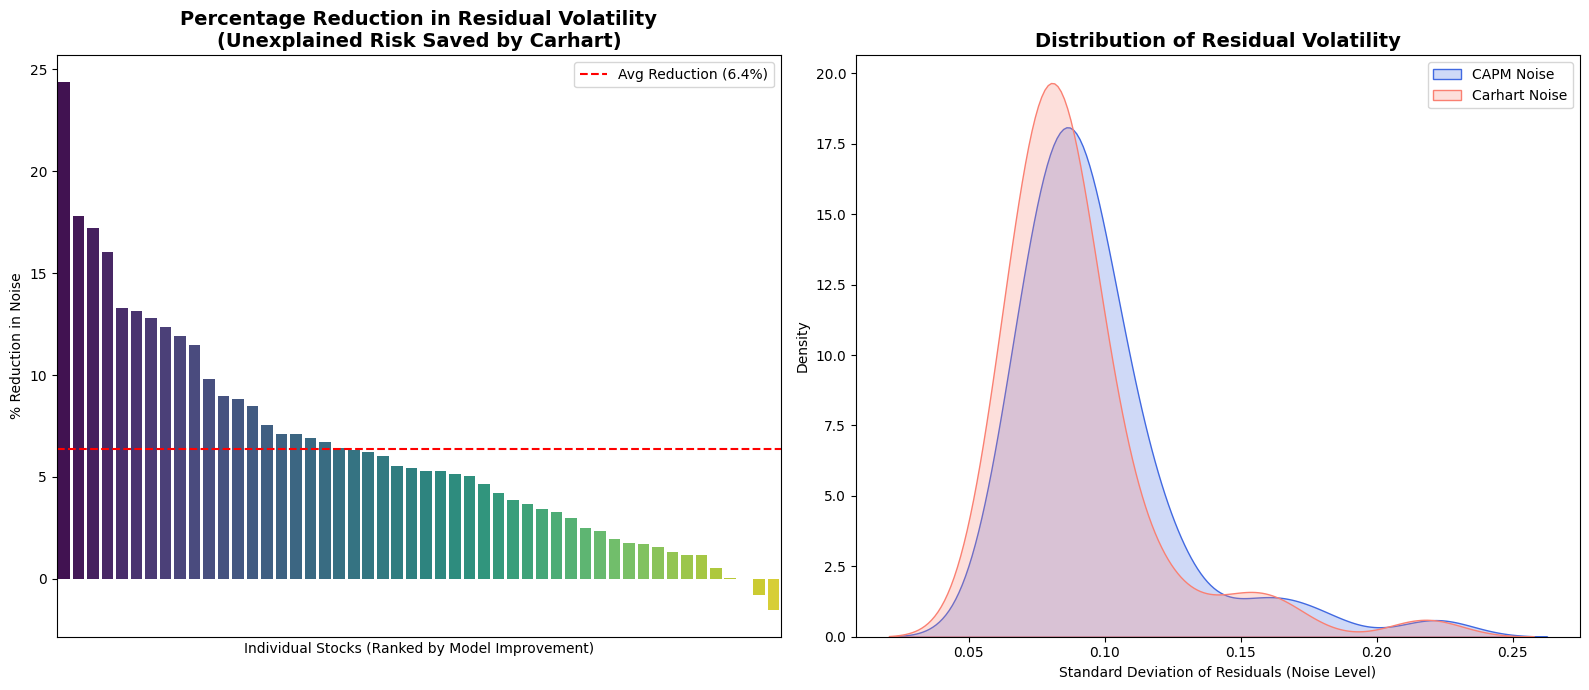

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD AND PREPARE DATA
# We use the processed file containing the 50 stocks and factors
df = pd.read_csv('Sorted_Asset_Pricing_Data.csv')
stocks = df['Co_Name'].unique()
rf_rate = 0.0045

# We focus on the In-Sample period (2018-2022) for this analysis
df_in_sample = df[df['Year'] <= 2022].copy()

res_vol_results = []

print("Starting Residual Volatility Analysis...")

# 2. CALCULATION LOOP
for stock in stocks:
    # Filter for the specific stock
    s_df = df_in_sample[df_in_sample['Co_Name'] == stock].dropna().copy()

    # Calculate Excess Returns (The Dependent Variable 'y')
    y = s_df['Stock_Return'] - rf_rate

    # Define Market Excess Return (The correction we discussed!)
    s_df['Mkt_RF'] = s_df['Market_Return'] - rf_rate

    # --- MODEL 1: CAPM ---
    X_capm = sm.add_constant(s_df['Mkt_RF'])
    model_capm = sm.OLS(y, X_capm).fit()

    # Residual Volatility = Square Root of the MSE of Residuals (accounts for n-k-1)
    capm_rv = np.sqrt(model_capm.mse_resid)

    # --- MODEL 2: CARHART 4-FACTOR ---
    X_multi = sm.add_constant(s_df[['Mkt_RF', 'SMB', 'HML', 'WML']])
    model_multi = sm.OLS(y, X_multi).fit()

    multi_rv = np.sqrt(model_multi.mse_resid)

    # Store the results
    res_vol_results.append({
        'Stock': stock,
        'CAPM_Res_Vol': capm_rv,
        'Multi_Res_Vol': multi_rv,
        'Noise_Reduction': capm_rv - multi_rv,
        'Pct_Reduction': ((capm_rv - multi_rv) / capm_rv) * 100
    })

# Convert to DataFrame
rv_df = pd.DataFrame(res_vol_results)

# 3. STATISTICAL SUMMARY
avg_capm = rv_df['CAPM_Res_Vol'].mean()
avg_multi = rv_df['Multi_Res_Vol'].mean()
avg_pct = rv_df['Pct_Reduction'].mean()

print("\n--- RESULTS SUMMARY ---")
print(f"Average CAPM Residual Volatility: {avg_capm:.4%}")
print(f"Average Multi-Factor Residual Volatility: {avg_multi:.4%}")
print(f"Average Reduction in 'Mystery' Risk: {avg_pct:.2f}%")

# 4. VISUALIZATION
plt.figure(figsize=(16, 7))

# Graph A: The Reduction Bar Chart
plt.subplot(1, 2, 1)
rv_df_sorted = rv_df.sort_values('Pct_Reduction', ascending=False)
sns.barplot(x='Stock', y='Pct_Reduction', data=rv_df_sorted, palette='viridis')
plt.axhline(avg_pct, color='red', linestyle='--', label=f'Avg Reduction ({avg_pct:.1f}%)')
plt.title('Percentage Reduction in Residual Volatility\n(Unexplained Risk Saved by Carhart)', fontsize=14, fontweight='bold')
plt.ylabel('% Reduction in Noise')
plt.xticks([]) # Hide X labels to keep it clean for 50 stocks
plt.xlabel('Individual Stocks (Ranked by Model Improvement)')
plt.legend()

# Graph B: The Distribution Comparison (Left-Shift is Winning!)
plt.subplot(1, 2, 2)
sns.kdeplot(rv_df['CAPM_Res_Vol'], fill=True, color='royalblue', label='CAPM Noise')
sns.kdeplot(rv_df['Multi_Res_Vol'], fill=True, color='salmon', label='Carhart Noise')
plt.title('Distribution of Residual Volatility', fontsize=14, fontweight='bold')
plt.xlabel('Standard Deviation of Residuals (Noise Level)')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.savefig('Residual_Volatility_Deep_Dive.png')
plt.show()

# Export for report tables
rv_df.to_csv('Final_Residual_Volatility_Comparison.csv', index=False)